In [1]:
# Import necessary libraries for data manipulation, visualization, and clustering.

import pandas as pd  # Used for data manipulation and analysis.
import matplotlib.pyplot as plt  # Used for creating static, interactive, and animated visualizations.

from sklearn.cluster import KMeans  # Used for K-Means clustering algorithm.
from sklearn.preprocessing import StandardScaler  # Used for standardizing features by removing the mean and scaling to unit variance.

### Load Dataset

This section loads the customer data from a CSV file into a pandas DataFrame.

In [2]:
df = pd.read_csv(
    "Mall_Customers.csv"  # Reads the 'Mall_Customers.csv' file into a pandas DataFrame named 'df'.
)


df.head()  # Displays the first 5 rows of the DataFrame to get a quick overview of the data.

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Select Features for Segmentation

Here, we select the relevant features from the DataFrame that will be used for customer segmentation.

In [3]:
# For Segmentation: Selecting specific columns for clustering.

X = df[
[
"Annual Income (k$)",  # Selects the 'Annual Income (k$)' column.
"Spending Score (1-100)"  # Selects the 'Spending Score (1-100)' column.
]
]  # Creates a new DataFrame 'X' containing only these two columns.

In [4]:
X  # Displays the selected features DataFrame 'X'.

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### Feature Scaling

Standardizing the features is crucial for clustering algorithms like K-Means, as it ensures that all features contribute equally to the distance calculations.

In [5]:
scaler = StandardScaler()  # Initializes the StandardScaler to normalize the data.

X_scaled = scaler.fit_transform(X)  # Fits the scaler to the data in 'X' and then transforms 'X', storing the result in 'X_scaled'.

### Find Optimal Number of Clusters (Elbow Method)

The Elbow Method is used to determine the optimal number of clusters for K-Means by plotting the Within-Cluster Sum of Squares (WCSS).

In [6]:
wcss=[]  # Initializes an empty list to store the WCSS (Within-Cluster Sum of Squares) values.


for i in range(1,11):  # Loops from 1 to 10 to test different numbers of clusters.

    kmeans = KMeans(
        n_clusters=i,  # Sets the number of clusters for the current iteration.
        random_state=42, # Sets a random seed for reproducibility.
        n_init=10 # Suppress the warning for n_init by explicitly setting its value
    )

    kmeans.fit(X_scaled)  # Fits the K-Means model to the scaled data.

    wcss.append(
        kmeans.inertia_  # Appends the WCSS value (inertia) for the current number of clusters.
    )

### Plotting the Elbow Method Results

This plot helps visualize the WCSS values against the number of clusters to identify the 'elbow' point, indicating the optimal number of clusters.

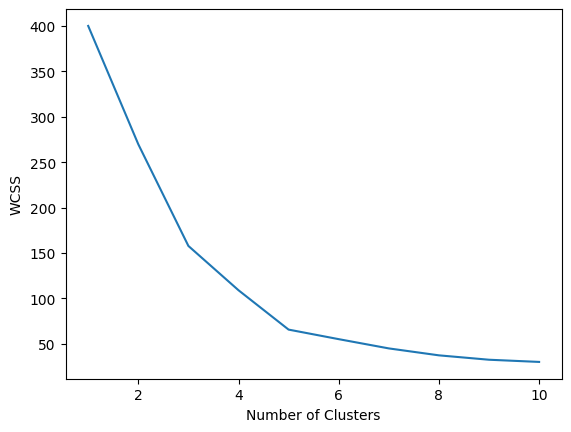

In [7]:
plt.plot(
range(1,11),  # X-axis: Number of clusters from 1 to 10.
wcss  # Y-axis: WCSS values corresponding to each number of clusters.
)

plt.xlabel(
"Number of Clusters"  # Labels the X-axis.
)

plt.ylabel(
"WCSS"  # Labels the Y-axis.
)

plt.show()  # Displays the plot.

### Apply K-Means Clustering

Based on the Elbow Method, K-Means clustering is applied with the optimal number of clusters.

In [8]:
kmeans = KMeans(
    n_clusters=5,  # Sets the number of clusters to 5, as suggested by the Elbow Method.
    random_state=42, # Sets a random seed for reproducibility.
    n_init=10 # Suppress the warning for n_init by explicitly setting its value
)


clusters = kmeans.fit_predict(
    X_scaled  # Predicts the cluster assignments for each data point in the scaled data.
)  # Stores the cluster labels in the 'clusters' variable.

### Add Cluster Column to DataFrame

The predicted cluster labels are added as a new column to the original DataFrame.

In [9]:
df["Cluster"] = clusters  # Adds a new column named "Cluster" to the original DataFrame 'df' with the assigned cluster labels.


df.head()  # Displays the first 5 rows of the DataFrame, now including the new "Cluster" column.

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Visualization of K-Means Clusters

The clusters are visualized on a scatter plot using 'Annual Income' and 'Spending Score' to show the distinct segments.

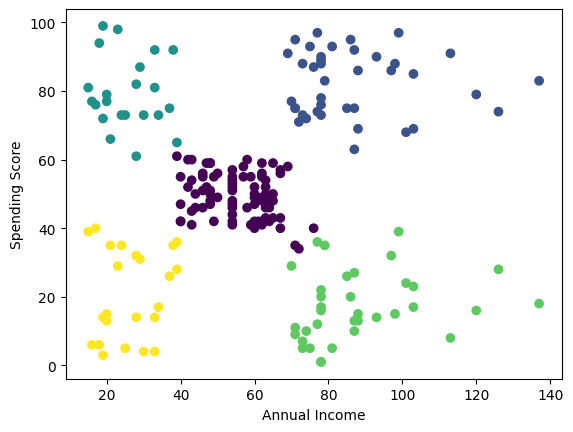

In [10]:
plt.scatter(
X.iloc[:,0],  # X-coordinate: 'Annual Income (k$)' (first column of X).
X.iloc[:,1],  # Y-coordinate: 'Spending Score (1-100)' (second column of X).
c=clusters  # Colors the points based on their assigned cluster.
)


plt.xlabel(
"Annual Income"  # Labels the X-axis.
)

plt.ylabel(
"Spending Score"  # Labels the Y-axis.
)


plt.show()  # Displays the scatter plot.

### 2. Hierarchical Clustering

This section explores customer segmentation using Hierarchical Clustering, an alternative clustering method.

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage  # Imports functions for hierarchical clustering visualization (dendrogram) and linkage calculation.

### Create Dendrogram

A dendrogram is generated to visually represent the hierarchical relationships between clusters and help determine the optimal number of clusters.

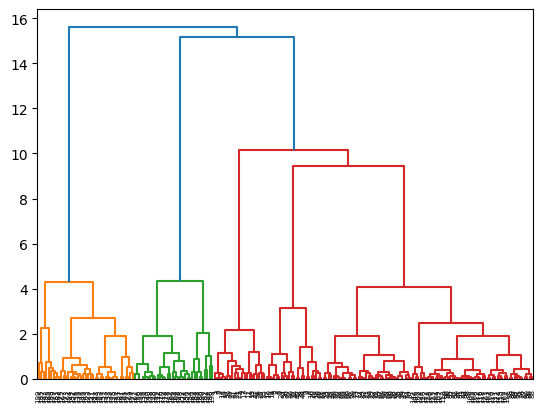

In [12]:
# How many clusters should we create? The dendrogram will help in determining this.

linked = linkage(
X_scaled,  # Uses the scaled features for hierarchical clustering.
method='ward'  # Specifies the linkage method as 'ward', which minimizes variance within each cluster.
)


dendrogram(
linked  # Generates the dendrogram from the linkage matrix.
)

plt.show()  # Displays the dendrogram plot.

### Apply Hierarchical Clustering

Agglomerative Hierarchical Clustering is applied with a specified number of clusters, based on observations from the dendrogram.

In [ ]:
from sklearn.cluster import AgglomerativeClustering  # Imports the AgglomerativeClustering class for hierarchical clustering.


hc = AgglomerativeClustering(
    n_clusters=5  # Sets the desired number of clusters to 5, as inferred from the dendrogram.
)


clusters = hc.fit_predict(
X_scaled  # Fits the hierarchical clustering model to the scaled data and predicts cluster assignments.
)  # Stores the cluster labels in the 'clusters' variable.

### Add Hierarchical Cluster Column

The cluster labels obtained from hierarchical clustering are added to the original DataFrame.

In [ ]:
df["Cluster"]=clusters  # Adds a new column named "Cluster" to the original DataFrame 'df' with the hierarchical cluster labels.

### Visualization of Hierarchical Clusters

The resulting clusters from hierarchical clustering are visualized to examine the customer segments.

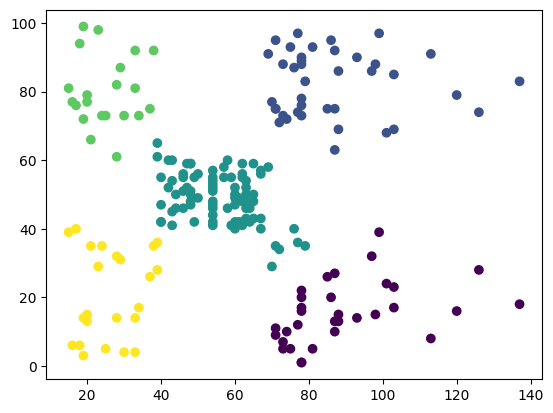

In [ ]:
plt.scatter(
X.iloc[:,0],  # X-coordinate: 'Annual Income (k$)' (first column of X).
X.iloc[:,1],  # Y-coordinate: 'Spending Score (1-100)' (second column of X).
c=clusters  # Colors the points based on their assigned hierarchical cluster.
)

plt.show()  # Displays the scatter plot of hierarchical clusters.